**Neural networks for road segmentation**
========================

Your next task is to train neural network to segment road on images from car cams.

The original dataset is provided by Karlsruhe Institute of Technology (http://www.cvlibs.net/datasets/kitti/eval_road.php). Their images are ±370x1270, but, for simlictiy, we will use 370x370 squares.

One can download the dataset from https://disk.yandex.ru/d/QPOw4hk84-se_w

Here is an example of input data with corresponding ground truth:

In [380]:
import os
import cv2
import numpy as np

import torchvision.transforms as transforms
import torchvision.transforms.v2 as v2
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch

import matplotlib.pyplot as plt
%matplotlib inline
from torch import optim

device = torch.device("cuda")

In [291]:
def get_paths(path):
    _, _, filenames = next(os.walk(path))

    images_paths = []
    for filename in sorted(filenames):            
        images_paths.append(os.path.join(path, filename))
    
    return np.stack(images_paths)

class RoadDataset(Dataset):
    """Feel free to rewrite it. For ex. cache all images in RAM to increase training speed"""
    def __init__(self, images, masks, transform, aug_crop=None, aug_color = None):
        self.images = sorted(images)
        self.masks = sorted(masks)
        self.transform = transform
        self.aug_crop = aug_crop
        self.aug_color = aug_color
        self.samples = []
        for idx in range(len(self.images)):
            im_name = self.images[idx]
            mask_name = self.masks[idx]
            
            image = cv2.imread(im_name)[:,:,::-1] / 255.0  # ::-1 to convert from BGR to RGB
            mask = cv2.imread(mask_name, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 0).astype(np.float32)
            

            sample = {
                'image': self.transform(image).float(),
                'mask': self.transform(mask).float(),
            }
            

            self.samples.append(sample)

    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        result = {}
        result['image'] = sample['image']
        result['mask'] = sample['mask']

        if self.aug_crop:
            state = torch.get_rng_state()
            result['image'] = self.aug_crop(result['image'])
            torch.set_rng_state(state)
            result['mask'] = self.aug_crop(result['mask'])

        if self.aug_color:
            result['image'] = self.aug_color(result['image'])
        return result

In [292]:
X_train = get_paths("data/train/images")
y_train = get_paths("data/train/gt")

X_test = get_paths("data/test/images")
y_test = get_paths("data/test/gt")

totensor = transforms.Compose([
    transforms.ToTensor(),
])

Введем всякхи аугментаций.

In [394]:
std = torch.tensor([0.2900, 0.3088, 0.3262])
mean = torch.tensor([0.3634, 0.3927, 0.3818])
transform_resize_random = transforms.Compose([
    transforms.RandomRotation(5,expand = False),
    transforms.RandomResizedCrop((256,256), scale=(0.5, 1.0), ratio=(0.8, 1.2)),
    transforms.RandomHorizontalFlip(),
])

transform_resize = transforms.Resize((256,256))

transform_color_random = transforms.Compose([
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.Normalize(mean, std),
])

transform_color = transforms.Normalize(mean, std)

def denormalize(image):
    return torch.clamp(image*std[:,None,None]+mean[:,None,None],0,1)

In [395]:
train_dataset = RoadDataset(X_train, y_train, totensor,transform_resize_random,transform_color_random)
test_dataset = RoadDataset(X_test, y_test, totensor,transform_resize,transform_color)

In [385]:
data_list = [train_dataset[i]['image'][None,:,:,:] for i in range(len(train_dataset))]
data_list = torch.cat(data_list,dim = 0)
print("mean = ",data_list.mean(dim=(0,2,3)))
print("std = ",data_list.std(dim=(0,2,3)))

mean =  tensor([-0.1739, -0.1991, -0.1910])
std =  tensor([0.9732, 0.9559, 0.9184])


Найдем дисбаласн классов.

In [475]:
data_list = [train_dataset[i]['mask'][None,:,:,:] for i in range(len(train_dataset))]
data_list = torch.cat(data_list,dim = 0)
class_disbalane = data_list.mean(dim=(0,2,3))
print("class_disbalane = ",class_disbalane)

class_disbalane =  tensor([0.1940])


Нарисуем картичноки

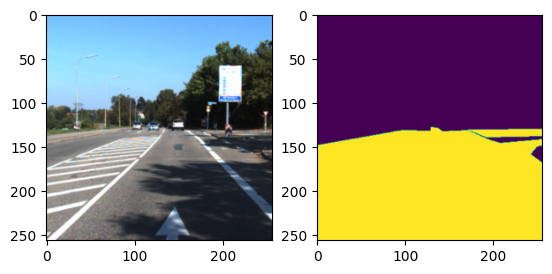

In [377]:
sample = test_dataset[114]
image = sample['image']
mask = sample['mask']

plt.subplot(1, 2, 1)
plt.imshow(denormalize(image).permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.imshow(mask.permute(1, 2, 0))
plt.show()

Посмотрим что случайные аугментации на обучающем множестве работают.

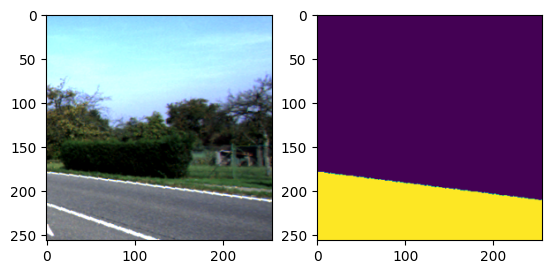

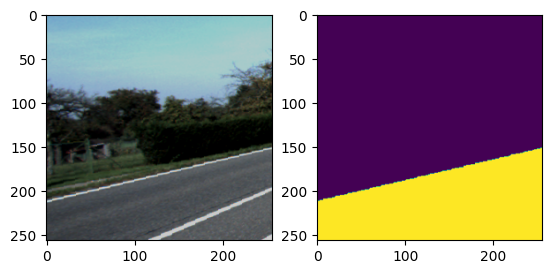

In [396]:
sample = train_dataset[114]
image = sample['image']
mask = sample['mask']

plt.subplot(1, 2, 1)
plt.imshow(denormalize(image).permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.imshow(mask.permute(1, 2, 0))
plt.show()

sample = train_dataset[114]
image = sample['image']
mask = sample['mask']

plt.subplot(1, 2, 1)
plt.imshow(denormalize(image).permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.imshow(mask.permute(1, 2, 0))
plt.show()

Workflow:
---
* Choose correct loss function, write training loop and code for testing. Feel free to use previous HW for inspiration. 
* Train any segmentation neural network from scratch (for example U-Net) and achieve >= 0.75 IoU on test set (40% points). See function to calculate the metric below.
* Use any pretrained model for image classification, convert it for segmentation by adding decoder (don't forget skip-connections) or usign dilated convolutions and achieve >= 0.87 IoU  on test set (60% points).

You're not allowed to do only one thing: train your network on test set.

----
Your final solution will consist of an ipython notebook with code (for final networks training + any experiments with data) and test metric calculation.

Feel free to ask in Telegram chat if something is not clear :3


Создадим UNet

In [397]:
class ConvBlock(nn.Module):
    """
    Helper module that consists of a Conv -> BN -> ReLU
    """

    def __init__(self, in_channels, out_channels, padding=1, kernel_size=3, stride=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, padding=padding, kernel_size=kernel_size, stride=stride)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.pooling = nn.MaxPool2d(kernel_size=2)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.pooling(x)
        x = self.relu(x)
        return x


In [398]:
class UpSpempleBlock(nn.Module):
    """
    Up block that encapsulates one up-sampling step which consists of Upsample -> ConvBlock -> ConvBlock
    """

    def __init__(self, in_channels, out_channels, res_channels, output_size,padding=1, kernel_size=3, stride=1):
        super().__init__()


        self.upsample = nn.Upsample(mode='bilinear', size = (output_size,output_size))
        self.conv = nn.Conv2d(in_channels+res_channels, out_channels, padding=padding, kernel_size=kernel_size, stride=stride)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

        self.conv_block_2 = ConvBlock(out_channels, out_channels)

    def forward(self, up_x, down_x = None):
        """

        :param up_x: this is the output from the previous up block
        :param down_x: this is the output from the down block
        :return: upsampled feature map
        """
        x = self.upsample(up_x)
        if down_x is not None:
            x = torch.cat([x, down_x], 1)
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

In [399]:
class UNet(nn.Module):
    
    def __init__(self,dims = [3,16,32,64,128,256],in_size = 256,bottel_neck = 256):
        super(UNet, self).__init__()
        self.dims = dims
        self.enc1 = ConvBlock(dims[0],dims[1])
        self.enc2 = ConvBlock(dims[1],dims[2])
        self.enc3 = ConvBlock(dims[2],dims[3])
        self.enc4 = ConvBlock(dims[3],dims[4])
        self.enc5 = ConvBlock(dims[4],dims[5])
        self.bride1 = nn.Linear(dims[5]*8*8,bottel_neck)
        self.bride2 = nn.Linear(bottel_neck,dims[5]*8*8)
        self.picture_size = [in_size//2**n for n in range(0,6)]

        self.dec4 = UpSpempleBlock(dims[5], dims[4], dims[4], self.picture_size[4])
        self.dec3 = UpSpempleBlock(dims[4], dims[3], dims[3], self.picture_size[3])
        self.dec2 = UpSpempleBlock(dims[3], dims[2], dims[2], self.picture_size[2])
        self.dec1 = UpSpempleBlock(dims[2], dims[1], dims[1], self.picture_size[1])
        self.dec0 = UpSpempleBlock(dims[1], dims[1], 0, self.picture_size[0])
        self.conv1 = nn.Conv2d(dims[1], 2, padding=0, kernel_size=1, stride=1)

    def forward(self, x):
        x1 = self.enc1(x)

        # тут я мучительно проверял что нигде не ошибся с размерами слоя
        #print("x1 = ",x1.shape)
        x2 = self.enc2(x1)
        #print("x2 = ",x2.shape)
        x3 = self.enc3(x2)
        #print("x3 = ",x3.shape)
        x4 = self.enc4(x3)
        #print("x4 = ",x4.shape)
        x5 = self.enc5(x4)
        #print("x5 = ",x5.shape)
        shape = x5.shape
        #print("x5_flat = ",torch.flatten(x5,start_dim=1).shape)
        #x5 (batch,dims[4],23,23)
        x5 = self.bride2(self.bride1(torch.flatten(x5,start_dim=1)))
        x5 = torch.reshape(x5,shape)
        e3 = self.dec4(x5,x4)
        #print("e3 = ",e3.shape)
        e2 = self.dec3(e3,x3)
        #print("e2 = ",e2.shape)
        e1 = self.dec2(e2,x2)
        #print("e1 = ",e1.shape)
        e0 = self.dec1(e1,x1)
        #print("e0 = ",e0.shape)
        e = self.dec0(e0)
        #print("e = ",e.shape)
        e = self.conv1(e)
        return e

Проверим что сетка работает

In [400]:
unet = UNet()
unet = unet.to(device)

BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,num_workers=4, pin_memory=True)

for batch in train_loader:
    break

x = batch['image']
x = x.to(device)
with torch.no_grad():
    unet.eval()
    res = unet(x)

In [401]:
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,num_workers=4, pin_memory=True)

In [402]:
unet = UNet()
unet = unet.to(device)
optimizer = optim.Adam(unet.parameters(),lr=1e-3)

Петля обучения. Не понял откуда эти пики на лосе.

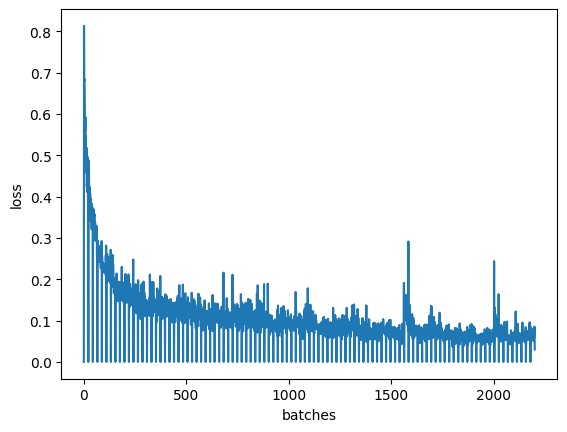

100%|██████████| 100/100 [08:40<00:00,  5.21s/it]


In [403]:
from itertools import islice
from IPython.display import clear_output
from tqdm import tqdm
#!L
# Train your autoencoder
# Visualize progress in reconstruction and loss decay

n_epoch = 100
ce_loss = torch.nn.CrossEntropyLoss()
# будем запоминать статистики по разным компонентам лоса и так же средние по mu_gen, logsigma_gen, mu_z, logsigma_z
hist = []
unet.train()

for epoch in tqdm(range(n_epoch)):
    hist.append(0)
    for batch in train_loader:
        
        x = batch['image']
        x = x.to(device)

        mask = batch['mask']
        mask = mask.to(device)
        ones = torch.ones_like(mask)
        mask = torch.cat([ones-mask,mask],dim=1)
        #mask = torch.squeeze(mask,dim = 1)
        
        optimizer.zero_grad()
        predictions = unet(x)
        loss = ce_loss(predictions,mask)
        loss.backward()
        optimizer.step()
        hist.append(loss.item())


    clear_output()

    #print(f"epoch = {epoch}")

    plt.plot(hist)
    plt.ylabel("loss")
    plt.xlabel("batches")
    plt.show()

Посмотрим что получилось, возьмем картинку и нарисуем её, маску и предсказания.

In [404]:
BATCH_SIZE = 8
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,num_workers=4, pin_memory=True)

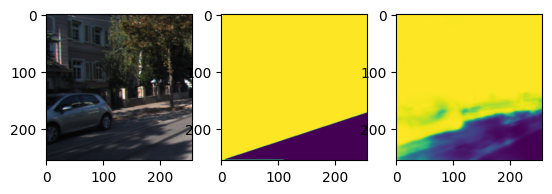

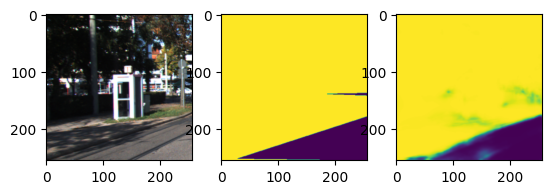

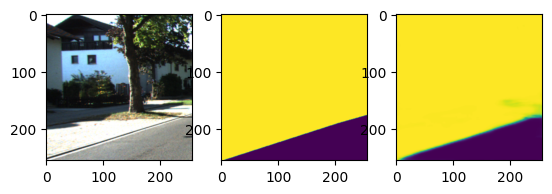

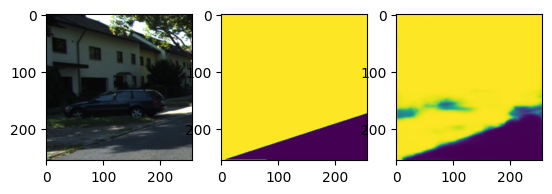

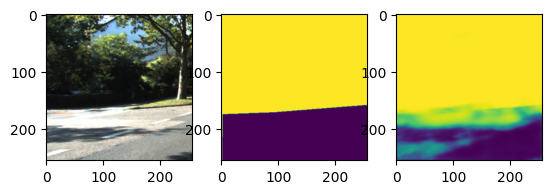

In [405]:
for batch in test_loader:
    with torch.no_grad():
        x = batch['image']
        x = x.to(device)

        mask = batch['mask']
        mask = mask.to(device)
        ones = torch.ones_like(mask)
        mask = torch.cat([ones-mask,mask],dim=1)
   
        unet.eval()
        predictions = unet(x)
    
    break
for k in range(5):
    image = x[k].cpu()
    mask2 = mask[k,0,:,:].cpu()[None,:,:]
    perd = predictions.softmax(dim=1)[k][0,:,:].detach().cpu()
    plt.subplot(1, 3, 1)
    plt.imshow(denormalize(image).permute(1, 2, 0))
    plt.subplot(1, 3, 2)
    plt.imshow(mask2.permute(1, 2, 0))
    plt.subplot(1, 3, 3)
    plt.imshow(perd[None,:,:].permute(1, 2, 0))
    plt.show()

Выглядит неплохо 

In [406]:
def calc_iou(prediction, ground_truth):
    n_images = len(prediction)
    intersection, union = 0, 0
    for i in range(n_images):
        intersection += np.logical_and(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum() 
        union += np.logical_or(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum()
    return float(intersection) / union

Посчитаем IOU по набору данных

In [421]:
def evaluate(model,loader, threshold = 0.5):
    iou = []
    model.eval()
    for batch in loader:
        with torch.no_grad():
            x = batch['image']
            x = x.to(device)

            mask = batch['mask'].numpy() 
            mask2 = batch['mask'] 
            
            logits = model(x)
            probab2 = logits.softmax(dim=1).detach().cpu()
            probab = logits.softmax(dim=1).detach().cpu().numpy()
            predictions = probab < threshold
            for k in range(predictions.shape[0]):
                
                iou.append(np.nan_to_num(calc_iou(predictions[k,0], mask[k,0])))
    return np.mean(iou)      



Попробуем подобрать порого на обучающем множестве.

In [431]:
thresholds = np.arange(0.1,0.9,0.05)
ious = []
for t in thresholds:
    ious.append(evaluate(unet,train_loader,threshold=t))

/tmp/ipykernel_6616/2556989676.py:7: RuntimeWarning: invalid value encountered in scalar divide
  return float(intersection) / union


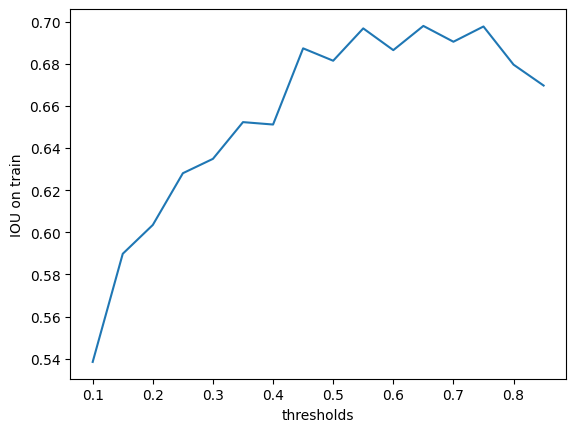

In [432]:
plt.plot(thresholds,ious)
plt.ylabel("IOU on train")
plt.xlabel("thresholds")
plt.show()


Вычислим IOU на тестовом множестве.

In [428]:
iou = evaluate(unet,test_loader,threshold=0.65)
print("IOU on test = ",iou)

IOU on test =  0.7500904


# !!!ПОБИЛ ПОРОГ!!!

Попробуем сделать тоже самое но с предобученной ResNet

In [442]:
import torchvision.models as models

resnt18 = models.resnet18(pretrained=True)

/home/eliyashev/SHAD/ML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/eliyashev/SHAD/ML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [443]:
resnt18

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Посмотрим как это выглядят размеры выходов реснета.

In [447]:
conv1 = resnt18.conv1
bn1 = resnt18.bn1
relu = resnt18.relu
maxpool = resnt18.maxpool
layer1 = resnt18.layer1
layer2 = resnt18.layer2
layer3 = resnt18.layer3
layer4 = resnt18.layer4
print("x shape = ", x.shape)
x1=maxpool(relu(bn1(conv1(x))))
print("x1 shape = ", x1.shape)
x2=layer1(x1)
print("x2 shape = ", x2.shape)
x3=layer2(x2)
print("x3 shape = ", x3.shape)
x4=layer3(x3)
print("x4 shape = ", x4.shape)
x5=layer4(x4)
print("x5 shape = ", x5.shape)

x shape =  torch.Size([8, 3, 256, 256])
x1 shape =  torch.Size([8, 64, 64, 64])
x2 shape =  torch.Size([8, 64, 64, 64])
x3 shape =  torch.Size([8, 128, 32, 32])
x4 shape =  torch.Size([8, 256, 16, 16])
x5 shape =  torch.Size([8, 512, 8, 8])


In [ ]:
class UpSpampleBlockResnet(nn.Module):
    """
    Up block that encapsulates one up-sampling step which consists of Upsample -> ConvBlock -> ConvBlock
    """

    def __init__(self, in_channels, out_channels, res_channels, output_size,padding=1, kernel_size=3, stride=1):
        super().__init__()


        self.upsample = nn.Upsample(mode='bilinear', size = (output_size,output_size))
        self.conv = nn.Conv2d(in_channels+res_channels, out_channels, padding=padding, kernel_size=kernel_size, stride=stride)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()


    def forward(self, up_x, down_x = None):
        """

        :param up_x: this is the output from the previous up block
        :param down_x: this is the output from the down block
        :return: upsampled feature map
        """
        x = self.upsample(up_x)
        if down_x is not None:
            x = torch.cat([x, down_x], 1)
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

Зададим нашу сетку на базе предобученной Resnet18

In [454]:
class UNetResnet18(nn.Module):
    
    def __init__(self,resnet18,in_size = 256,bottel_neck = 512):
        super(UNetResnet18, self).__init__()
        self.resnet18 = resnet18
        self.resnet_dim = [64,64,128,256,512]
        self.bride1 = nn.Linear(self.resnet_dim[-1]*8*8,bottel_neck)
        self.bride2 = nn.Linear(bottel_neck,self.resnet_dim[-1]*8*8)
        self.picture_size = [256,64,64,32,16,8]

        dim = self.resnet_dim
        self.dec4 = UpSpampleBlockResnet(dim[4], dim[3], dim[3], self.picture_size[4])
        self.dec3 = UpSpampleBlockResnet(dim[3], dim[2], dim[2], self.picture_size[3])
        self.dec2 = UpSpampleBlockResnet(dim[2], dim[1], dim[1], self.picture_size[2])
        self.dec1 = UpSpampleBlockResnet(dim[1], dim[0], dim[0], self.picture_size[1])
        self.dec0 = UpSpampleBlockResnet(dim[0], dim[0], 0, self.picture_size[0])
        self.out = nn.Conv2d(dim[0], 2, padding=0, kernel_size=1, stride=1)

    def forward(self, x):

        conv1 = self.resnet18.conv1
        bn1 = self.resnet18.bn1
        relu = self.resnet18.relu
        maxpool = self.resnet18.maxpool
        layer1 = self.resnet18.layer1
        layer2 = self.resnet18.layer2
        layer3 = self.resnet18.layer3
        layer4 = self.resnet18.layer4
        x1=maxpool(relu(bn1(conv1(x))))
        x2=layer1(x1)
        x3=layer2(x2)
        x4=layer3(x3)
        x5=layer4(x4)

        shape = x5.shape
        x5 = self.bride2(self.bride1(torch.flatten(x5,start_dim=1)))
        e = torch.reshape(x5,shape)

        e = self.dec4(e,x4)
        e = self.dec3(e,x3)
        e = self.dec2(e,x2)
        e = self.dec1(e,x1)
        e = self.dec0(e)
        e = self.out(e)
        return e

Возьмем шедулер с прошлой домашки.

In [492]:
class StepLRWithWarmup(torch.optim.lr_scheduler.LRScheduler):
    def __init__(self, optimizer, step_size, gamma=0.1, warmup_epochs=3, warmup_lr_init=1e-5, 
                 min_lr=1e-5,
                 last_epoch=-1, verbose=False):
        self.step_size = step_size
        self.gamma = gamma
        self.warmup_epochs = warmup_epochs
        self.warmup_lr_init = warmup_lr_init
        self.min_lr = min_lr
        
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        # if not self._get_lr_called_within_step:
        #     warnings.warn("To get the last learning rate computed by the scheduler, "
        #                   "please use `get_last_lr()`.", UserWarning)
            
        if (self.last_epoch == 0):
            return [self.warmup_lr_init for _ in self.optimizer.param_groups]
        elif self.last_epoch <= self.warmup_epochs:
            return [self.warmup_lr_init + (self.base_lrs[i]-self.warmup_lr_init)*self.last_epoch/self.warmup_epochs for i in range(len(self.optimizer.param_groups))]
        elif (self.last_epoch - self.warmup_epochs)%self.step_size != 0:
            return [group['lr'] for group in self.optimizer.param_groups]
        elif (self.last_epoch - self.warmup_epochs)%self.step_size == 0:
            return [group['lr']*self.gamma if group['lr']*self.gamma >= self.min_lr else  group['lr'] for group in self.optimizer.param_groups]
        else:
            return [group['lr'] for group in self.optimizer.param_groups]

In [457]:
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,num_workers=4, pin_memory=True)

Инициализируем всё.

In [ ]:
WARMUP_LR_INIT = 1e-5
WARMUP_EPOCHS = 10
STEP_SIZE = 10
GAMMA = 0.5
MIN_LR = 1e-5
OPT_LR = 1e-3



resnet18 = models.resnet18(pretrained=True)
uresnet = UNetResnet18(resnet18)
uresnet = uresnet.to(device)
optimizer = optim.Adam(uresnet.parameters(),lr=1e-3)
# возьмем шедулел из домашки 2
scheduler = StepLRWithWarmup(optimizer, step_size=STEP_SIZE, gamma=GAMMA, 
                                      warmup_epochs=WARMUP_EPOCHS, warmup_lr_init=WARMUP_LR_INIT,
                                      min_lr=MIN_LR)


Петля обучения.

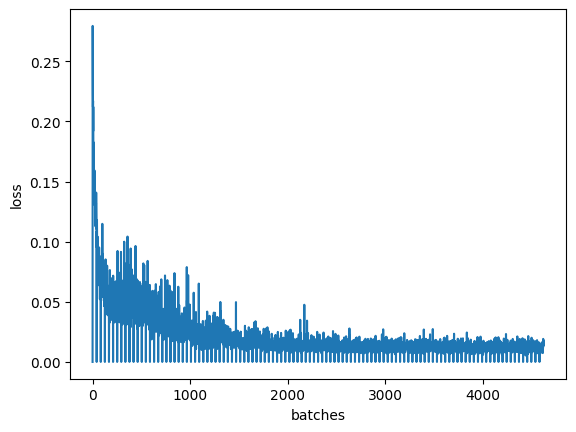

100%|██████████| 50/50 [07:46<00:00,  9.32s/it]


In [500]:
from itertools import islice
from IPython.display import clear_output
from tqdm import tqdm

# добавим веса классов
weight = torch.tensor([0.2,1],device=device)
n_epoch = 50
ce_loss = torch.nn.CrossEntropyLoss(weight=weight)
hist = []
uresnet.train()

for epoch in tqdm(range(n_epoch)):
    hist.append(0)
    for batch in train_loader:
        
        x = batch['image']
        x = x.to(device)

        mask = batch['mask']
        mask = mask.to(device)
        ones = torch.ones_like(mask)
        mask = torch.cat([ones-mask,mask],dim=1)
        #mask = torch.squeeze(mask,dim = 1)
        
        optimizer.zero_grad()
        predictions = uresnet(x)
        loss = ce_loss(predictions,mask)
        loss.backward()
        optimizer.step()
        hist.append(loss.item())
    scheduler.step()

    clear_output()

    #print(f"epoch = {epoch}")

    plt.plot(hist)
    plt.ylabel("loss")
    plt.xlabel("batches")
    plt.show()

Нарисуем резульаты.

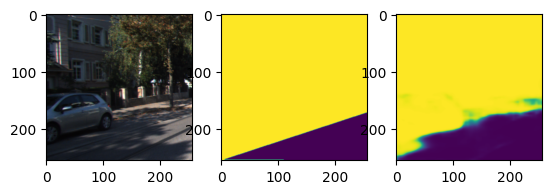

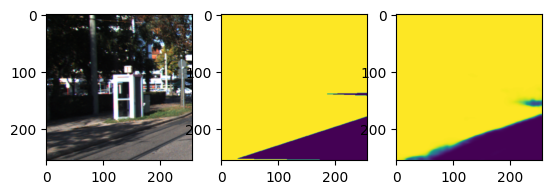

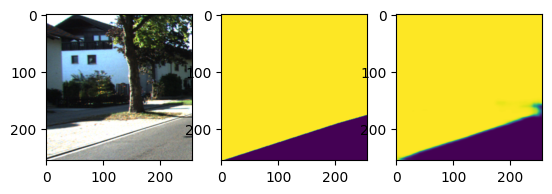

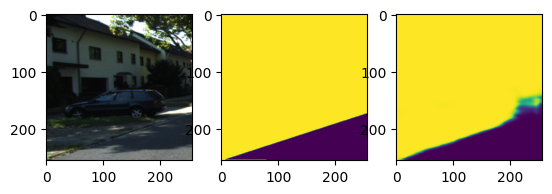

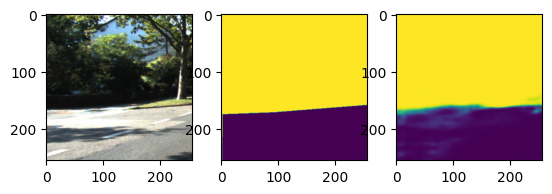

In [518]:
for batch in test_loader:
    with torch.no_grad():
        x = batch['image']
        x = x.to(device)

        mask = batch['mask']
        mask = mask.to(device)
        ones = torch.ones_like(mask)
        mask = torch.cat([ones-mask,mask],dim=1)
   
        uresnet.eval()
        predictions = uresnet(x)
    
    break
for k in range(5):
    image = x[k].cpu()
    mask2 = mask[k,0,:,:].cpu()[None,:,:]
    perd = predictions.softmax(dim=1)[k][0,:,:].detach().cpu()
    plt.subplot(1, 3, 1)
    plt.imshow(denormalize(image).permute(1, 2, 0))
    plt.subplot(1, 3, 2)
    plt.imshow(mask2.permute(1, 2, 0))
    plt.subplot(1, 3, 3)
    plt.imshow(perd[None,:,:].permute(1, 2, 0))
    plt.show()

Выгядит неплохо

Попробуем подобрать пороги между классами.

In [520]:
thresholds = np.arange(0.1,0.9,0.05)
ious = []
for t in thresholds:
    ious.append(evaluate(uresnet,train_loader,threshold=t))

/tmp/ipykernel_6616/2556989676.py:7: RuntimeWarning: invalid value encountered in scalar divide
  return float(intersection) / union


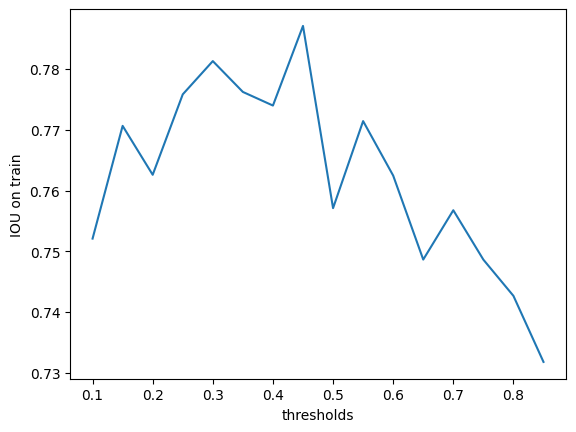

In [521]:
plt.plot(thresholds,ious)
plt.ylabel("IOU on train")
plt.xlabel("thresholds")
plt.show()

In [522]:
iou = evaluate(uresnet,test_loader,threshold=0.45)
print("IOU on test = ",iou)

IOU on test =  0.8310651


#### Пороги не удалось побить.

#### Выводы
Обучил две сетки одна Unet c нуля, другая берущая вкачестве энкодера Resnet18.
Я попробовал применять аугментаци, веса классов, шедулер и выбор порого между классами. Полной победы достичь не удалось: пороги побились только для первой сетки.

Dataset is small so actively use data augmentation: rotations, flip, color-change etc. to prevent overfitting.

Most likely you'll have to pad your images to 512x512 (it divides by 2^5=32, like U-Net wants). Use PadIfNeeded from Albumentations and central crop (see below) after prediction to calculate loss/metrics (you don't want to pay attention on padded values).

----
There is a hard data class imbalance in dataset, so the network output will be biased toward "zero" class. You can either tune the minimal probability threshold for the "road" class, or add class weights in optimized loss. You also can try to use softIoU or DICE loss.

Good luck!

In [216]:
def calc_iou(prediction, ground_truth):
    n_images = len(prediction)
    intersection, union = 0, 0
    for i in range(n_images):
        intersection += np.logical_and(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum() 
        union += np.logical_or(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum()
    return float(intersection) / union

In [8]:
def central_crop(images, size):
    current_size = images.size(2)
    border_len = (current_size - size) // 2
    images = images[:, :, border_len:current_size-border_len, border_len:current_size-border_len]